# Heart Disease Prediction

### Explore the dataset

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path("../data/heart+disease/processed.cleveland.data")

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv(
    data_path,
    header=None,
    names=columns,
    na_values="?"
)

df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [5]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [6]:
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

### Clean the dataset which has NaN values

In [7]:
df_clean = df.copy()

df_clean["ca"] = df_clean["ca"].fillna(df_clean["ca"].mode()[0])
df_clean["thal"] = df_clean["thal"].fillna(df_clean["thal"].mode()[0])

df_clean.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


### Check feature types

In [9]:
continuous_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

categorical_features = [
    "sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"
]

target = "target"

print("Continuous:", continuous_features)
print("Categorical:", categorical_features)
print("Target:", target)

Continuous: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Target: target


### Quick Sanity Check

In [10]:
for col in categorical_features:
    print(col)
    print(df_clean[col].value_counts().sort_index())
    print()

sex
sex
0.0     97
1.0    206
Name: count, dtype: int64

cp
cp
1.0     23
2.0     50
3.0     86
4.0    144
Name: count, dtype: int64

fbs
fbs
0.0    258
1.0     45
Name: count, dtype: int64

restecg
restecg
0.0    151
1.0      4
2.0    148
Name: count, dtype: int64

exang
exang
0.0    204
1.0     99
Name: count, dtype: int64

slope
slope
1.0    142
2.0    140
3.0     21
Name: count, dtype: int64

ca
ca
0.0    180
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64

thal
thal
3.0    168
6.0     18
7.0    117
Name: count, dtype: int64



### Check continous feature range

In [11]:
df_clean[continuous_features].describe()

,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


In [13]:
for col in categorical_features:
    unique_count = df_clean[col].nunique()
    unique_values = sorted(df_clean[col].unique())
    print(f"{col}: {unique_count} categories -> {unique_values}")

sex: 2 categories -> [np.float64(0.0), np.float64(1.0)]
cp: 4 categories -> [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
fbs: 2 categories -> [np.float64(0.0), np.float64(1.0)]
restecg: 3 categories -> [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
exang: 2 categories -> [np.float64(0.0), np.float64(1.0)]
slope: 3 categories -> [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
ca: 4 categories -> [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]
thal: 3 categories -> [np.float64(3.0), np.float64(6.0), np.float64(7.0)]


## Start Exploratory Data Analysis

### Which feature seems related to heart disease

In [14]:
df_clean["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

In [15]:
df_clean["target"].value_counts(normalize=True) * 100

target
0    54.125413
1    45.874587
Name: proportion, dtype: float64

This means dataset is fairly balanced

### Compare heart disease by sex

In [16]:
pd.crosstab(df_clean["sex"], df_clean["target"])

target,0,1
sex,,
0.0,72,25
1.0,92,114


In [17]:
pd.crosstab(df_clean["sex"], df_clean["target"], normalize="index") * 100

target,0,1
sex,,
0.0,74.226804,25.773196
1.0,44.660194,55.339806


This tells us, within each sex group, what percentage had heart disease.

But be careful: this dataset has many more males than females:

female: 97
male: 206

So we should not make a strong medical conclusion from this dataset alone

### Compare chest pain type with target

In [18]:
pd.crosstab(df_clean["cp"], df_clean["target"])

target,0,1
cp,,
1.0,16,7
2.0,41,9
3.0,68,18
4.0,39,105


In [19]:
pd.crosstab(df_clean["cp"], df_clean["target"], normalize="index") * 100

target,0,1
cp,,
1.0,69.565217,30.434783
2.0,82.000000,18.000000
3.0,79.069767,20.930233
4.0,27.083333,72.916667


In this dataset, patients with cp = 4 have a much higher proportion of heart disease.

### Visualize the relationships

import libraries associated to plotting graphs

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

1) Target count plot

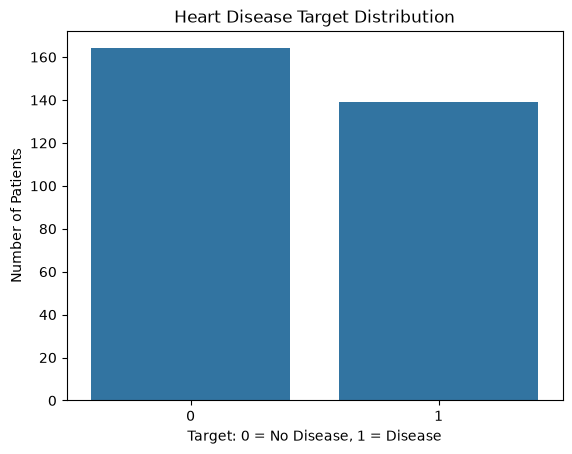

In [23]:
sns.countplot(data=df_clean, x="target")
plt.title("Heart Disease Target Distribution")
plt.xlabel("Target: 0 = No Disease, 1 = Disease")
plt.ylabel("Number of Patients")
plt.show()

2) Chest pain vs target

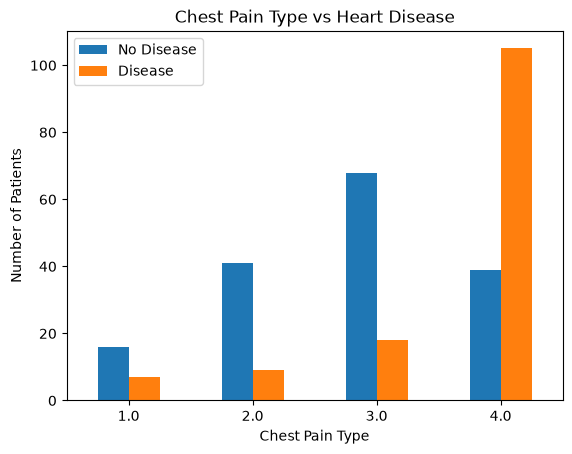

In [24]:
pd.crosstab(df_clean["cp"], df_clean["target"]).plot(kind="bar")

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation=0)
plt.show()

3) Age distribution

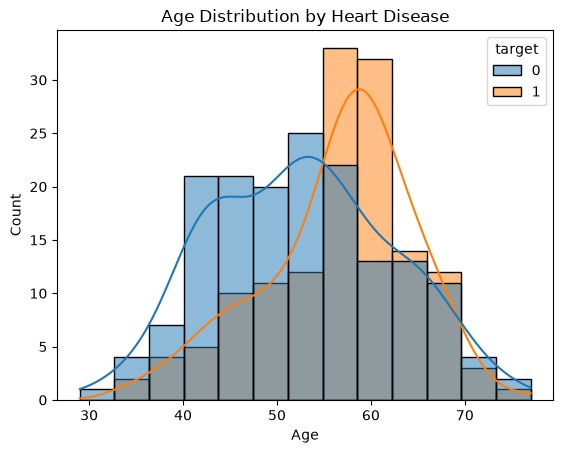

In [26]:
sns.histplot(data=df_clean, x="age", hue="target", kde=True)

plt.title("Age Distribution by Heart Disease")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

5) Max heart rate vs age

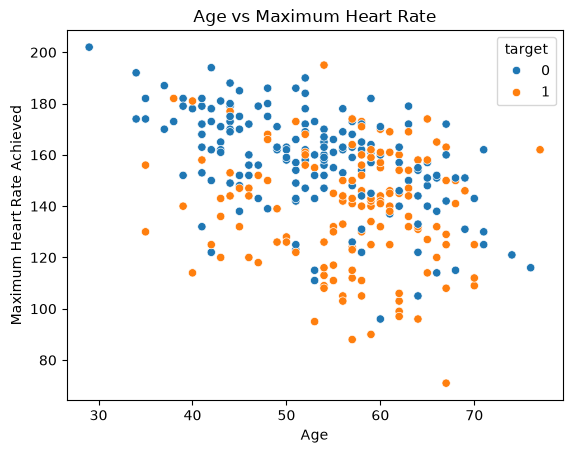

In [27]:
sns.scatterplot(
    data=df_clean,
    x="age",
    y="thalach",
    hue="target"
)

plt.title("Age vs Maximum Heart Rate")
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate Achieved")
plt.show()

## Correlation heatmap

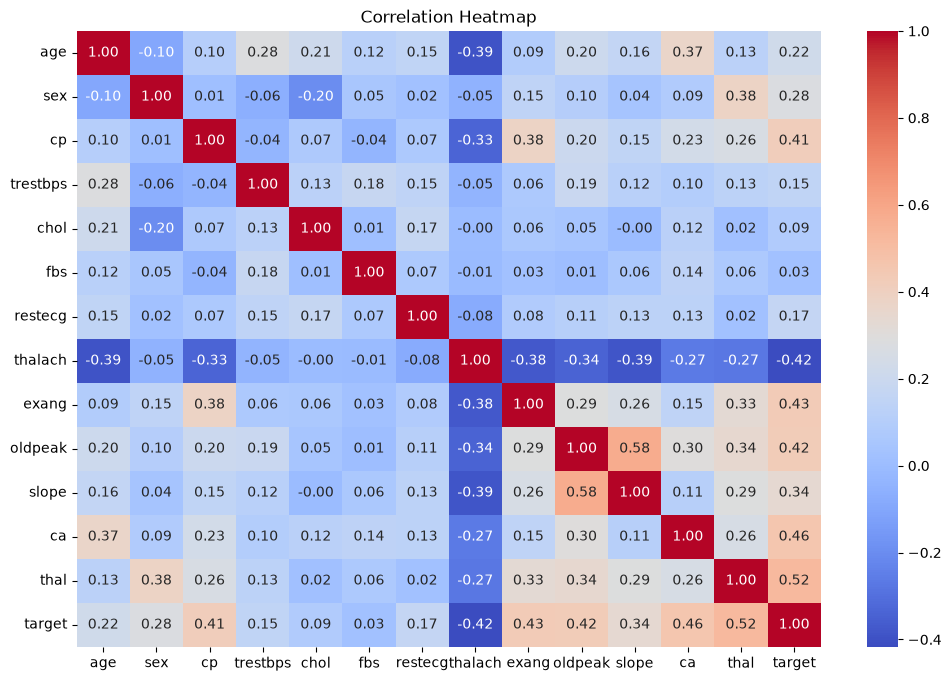

In [28]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Meaning: in this dataset, patients with heart disease generally have lower maximum heart rate achieved during exercise.

## Prepare data for ML

Now we move from EDA to modeling.

In [29]:
X = df_clean.drop("target", axis=1)
y = df_clean["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (303, 13)
y shape: (303,)


## Train/test split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (242, 13)
X_test: (61, 13)
y_train: (242,)
y_test: (61,)


Now we split the dataset into two Train and Test 
test_size=0.2 : means that the ratio of train:test dataset is set to 80:20 ratio    
random_state=42 : means that it makes the split reproducible, without keeping None, we put a number 42 or any number so that the shuffle will be identical every single time you run the code. You will get the exact same rows in your training set and the exact same rows in your testing set.   
stratify = y : it keeps the class balance in train and test as it is balanced in overall dataset when its split

## First baseline model

### As the first baseline model, we will use LOGISTIC REGRESSION

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8688524590163934


d:\Abdul Rahman\Engineering_UOM\Personal Projects\1) Heart Disease Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Proper preprocessing with StandardScaler

We will use:

StandardScaler

It transforms numerical values so they have:

mean ≈ 0
standard deviation ≈ 1

Example:

cholesterol 240
age 55
oldpeak 1.5

are brought into comparable scale.

Important: we fit the scaler only on training data, not the full dataset.

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

model_scaled = LogisticRegression(max_iter=1000)

model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

print("Scaled Logistic Regression Accuracy:", accuracy_scaled)

Scaled Logistic Regression Accuracy: 0.8688524590163934


## Evaluate beyond accuracy

In [33]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_scaled))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_scaled))

Confusion Matrix:
[[27  6]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



What confusion matrix means

It will look like this:

[[TN FP]
 [FN TP]]

Meaning:

TN = actually no disease, predicted no disease
FP = actually no disease, predicted disease
FN = actually disease, predicted no disease
TP = actually disease, predicted disease

For medical prediction, false negative is dangerous.

False negative means:

Patient has heart disease, but model says no disease

## Understand precision, recall, and F1

### Precision : Of all predicted as disease, how many are actually diseased? 
Prec = TP/(FP+TP)

### Recall : Of all actual disease, how many did the model catch?
Recall = TP/(FN+TP)

### F1 : Balance between precision and recall

## Compare with other models

Now we will compare,        
Logistic Regression         
K-Nearest Neighbors          
Decision Tree   
Random Forest

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    preds = clf.predict(X_test_scaled)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision_Disease": precision_score(y_test, preds),
        "Recall_Disease": recall_score(y_test, preds),
        "F1_Disease": f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision_Disease,Recall_Disease,F1_Disease
0,Logistic Regression,0.868852,0.812500,0.928571,0.866667
1,KNN,0.786885,0.741935,0.821429,0.779661
2,Decision Tree,0.721311,0.657143,0.821429,0.730159
3,Random Forest,0.901639,0.843750,0.964286,0.900000


## Sort by recall

In [35]:
results_df.sort_values(by="Recall_Disease", ascending=False)

,Model,Accuracy,Precision_Disease,Recall_Disease,F1_Disease
3,Random Forest,0.901639,0.843750,0.964286,0.900000
0,Logistic Regression,0.868852,0.812500,0.928571,0.866667
1,KNN,0.786885,0.741935,0.821429,0.779661
2,Decision Tree,0.721311,0.657143,0.821429,0.730159


### NEVER BLINDLY PICK THE MODEL WITH HIGHEST RECALL, Since even a model which predicts all data as disease will give recall 1.0, hence it is useless. Therefore we check Accuracy, Precision, and F1 as well and arrive at a conclusion ON THIS TRAIN/TEST Split random forest performed best

## Check Random Forest confusion matrix

In [36]:
best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train_scaled, y_train)

rf_preds = best_model.predict(X_test_scaled)

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_preds))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_preds))

Random Forest Confusion Matrix:
[[28  5]
 [ 1 27]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



## Cross-validation

In [37]:
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(
    RandomForestClassifier(random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Random Forest CV scores:", rf_cv_scores)
print("Mean CV accuracy:", rf_cv_scores.mean())
print("Standard deviation:", rf_cv_scores.std())

Random Forest CV scores: [0.87755102 0.79591837 0.8125     0.75       0.79166667]
Mean CV accuracy: 0.8055272108843538
Standard deviation: 0.04148195905476438


## Compare models using cross-validation

In [38]:
from sklearn.model_selection import cross_validate

cv_results = []

for name, clf in models.items():
    scores = cross_validate(
        clf,
        X_train_scaled,
        y_train,
        cv=5,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1"
        }
    )
    
    cv_results.append({
        "Model": name,
        "CV_Accuracy_Mean": scores["test_accuracy"].mean(),
        "CV_Precision_Mean": scores["test_precision"].mean(),
        "CV_Recall_Mean": scores["test_recall"].mean(),
        "CV_F1_Mean": scores["test_f1"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.sort_values(by="CV_Recall_Mean", ascending=False)

,Model,CV_Accuracy_Mean,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean
0,Logistic Regression,0.830442,0.846320,0.774308,0.807062
1,KNN,0.809779,0.822735,0.756126,0.785394
3,Random Forest,0.805527,0.822403,0.737945,0.775638
2,Decision Tree,0.743537,0.734967,0.683399,0.707783


This is a great lesson: the model that wins on one test split is not always the model that wins overall.

Why Random Forest looked best earlier

Earlier Random Forest got:

Test accuracy = 90.16%
Disease recall = 96.43%

But that was only one test split. That split may have been favorable for Random Forest.

Cross-validation tested 5 different folds, and Random Forest averaged:

CV accuracy = 80.55%
CV recall = 73.79%

So Random Forest is not clearly better. It may be overfitting or just more sensitive to small data.

Current best model choice

For now, I would choose:

Logistic Regression

Reasons:

Highest mean CV accuracy
Highest mean CV recall
Highest mean CV F1
Simple and explainable
Works well on small datasets

This is also more defensible in a medical-style project because explainability matters.

## Final evaluation of selected model

In [39]:
final_model = LogisticRegression(max_iter=1000)

final_model.fit(X_train_scaled, y_train)

final_preds = final_model.predict(X_test_scaled)

print("Final Model: Logistic Regression")
print("Accuracy:", accuracy_score(y_test, final_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_preds))

print("\nClassification Report:")
print(classification_report(y_test, final_preds))

Final Model: Logistic Regression
Accuracy: 0.8688524590163934

Confusion Matrix:
[[27  6]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



## Check predicted probabilities

In [40]:
final_probs = final_model.predict_proba(X_test_scaled)

final_probs[:5]

array([[0.7981027 , 0.2018973 ],
       [0.27644006, 0.72355994],
       [0.92746356, 0.07253644],
       [0.96150452, 0.03849548],
       [0.43690643, 0.56309357]])

This gives two probabilities per patient:

[probability of class 0, probability of class 1]

Now show class 1 disease probability:

In [41]:
disease_probs = final_model.predict_proba(X_test_scaled)[:, 1]

prob_df = X_test.copy()
prob_df["actual"] = y_test.values
prob_df["predicted"] = final_preds
prob_df["disease_probability"] = disease_probs

prob_df[["actual", "predicted", "disease_probability"]].head(10)

,actual,predicted,disease_probability
219,0,0,0.201897
271,0,1,0.723560
89,0,0,0.072536
101,0,0,0.038495
67,0,1,0.563094
244,0,0,0.036663
185,0,0,0.127780
233,0,0,0.226274
168,1,1,0.803637
197,0,0,0.318693


A class prediction only says:

disease / no disease

But probability gives more useful information:

Patient A: 0.91 probability of disease
Patient B: 0.53 probability of disease

Those are very different levels of confidence.

In real medical screening, borderline cases may be sent for further testing.

## Try different thresholds

In [42]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = []

for threshold in thresholds:
    threshold_preds = (disease_probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, threshold_preds).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, threshold_preds),
        "Precision": precision_score(y_test, threshold_preds),
        "Recall": recall_score(y_test, threshold_preds),
        "F1": f1_score(y_test, threshold_preds),
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,Threshold,Accuracy,Precision,Recall,F1,FP,FN,TP,TN
0,0.3,0.819672,0.717949,1.000000,0.835821,11,0,28,22
1,0.4,0.868852,0.812500,0.928571,0.866667,6,2,26,27
2,0.5,0.868852,0.812500,0.928571,0.866667,6,2,26,27
3,0.6,0.885246,0.862069,0.892857,0.877193,4,3,25,29
4,0.7,0.901639,0.892857,0.892857,0.892857,3,3,25,30


For a heart disease screening model, I would usually prefer:

low false negatives
high recall
acceptable false positives

Because a false positive can lead to extra testing, but a false negative can miss a sick patient.

But I don’t overclaim. This dataset is small and old. This model is educational, not clinically deployable.

Threshold 0.3:
- safest for avoiding missed disease
- highest false positives

Threshold 0.4 or 0.5:
- balanced
- FN = 2
- FP = 6
- accuracy = 86.89%

Threshold 0.6:
- higher accuracy
- fewer false positives
- more false negatives

Threshold 0.7:
- highest accuracy
- but still FN = 3

For a screening tool, I would choose either:

0.3 if the goal is maximum safety, no missed disease
0.4 if we want a balanced screening threshold

I would not choose 0.6 or 0.7 for screening because they miss more disease patients.

## Plot threshold tradeoff

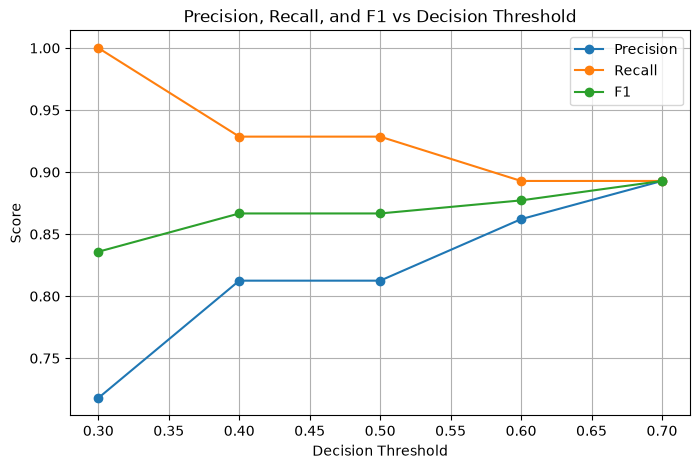

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(threshold_results_df["Threshold"], threshold_results_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["F1"], marker="o", label="F1")

plt.title("Precision, Recall, and F1 vs Decision Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

## Choose final threshold

threshold 0.3 → FN = 0, FP = 11, recall = 1.00              
threshold 0.4 → FN = 2, FP = 6, recall = 0.93               
threshold 0.5 → FN = 2, FP = 6, recall = 0.93               
threshold 0.6 → FN = 3, FP = 4, recall = 0.89               
threshold 0.7 → FN = 3, FP = 3, recall = 0.89               

For a screening-focused model, I would choose:          

threshold = 0.3

### Since this is a heart disease screening-style task, recall is prioritized over precision. A lower threshold such as 0.3 reduces false negatives, but increases false positives. The final threshold should be selected based on clinical risk and follow-up testing cost.

## Save the final model and scaler

In [45]:
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

joblib.dump(final_model, models_dir / "logistic_regression_model.pkl")
joblib.dump(scaler, models_dir / "standard_scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [46]:
print(list(models_dir.iterdir()))

[WindowsPath('../models/logistic_regression_model.pkl'), WindowsPath('../models/standard_scaler.pkl')]


In [47]:
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

threshold_results_df.to_csv(results_dir / "threshold_results.csv", index=False)
cv_results_df.to_csv(results_dir / "cross_validation_results.csv", index=False)

print("Results saved successfully.")

Results saved successfully.
